   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25
   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       5
1         8.3014     37.86    -122.22       5
2         7.2574     37.85    -122.24       5
3         5.6431     37.85    -122.25       5
4         3.8462     37.85    -122.25       1


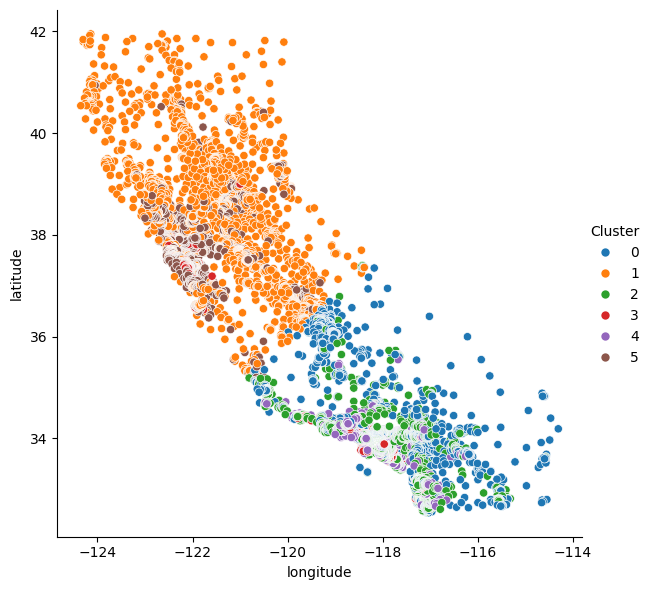

In [1]:
## Resonemangsfraga 7 - The code below uses the "housing.csv" dataset from Chapter 2

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("housing.csv")
X = df.loc[:, ["median_income", "latitude", "longitude"]]
print(X.head())

kmeans = KMeans(n_clusters=6)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")
print(X.head())

sns.relplot(
    x="longitude", y="latitude", hue="Cluster", data=X, height=6,
)

**a) Explain what the code does.**

The code loads `housing.csv` (the same California housing dataset from the Chapter 2 code example, "Ett kodexempel fran borjan till slut - Huspriser i Kalifornien", p. 63) and keeps only three columns: `median_income`, `latitude` and `longitude`. It then creates a `KMeans` model with `n_clusters=6` and calls `.fit_predict(X)`, which - per Faktafraga 2's explanation above - both trains the model (finds 6 centroids in this 3-dimensional feature space by repeatedly assigning points to their nearest centroid and recomputing centroids) and immediately returns, for every row, the index of the cluster it was assigned to. That result is stored in a new `Cluster` column, converted to a categorical type (so seaborn treats the 6 cluster labels as distinct colours rather than as a numeric scale), and finally `sns.relplot` draws a scatter plot of every house's geographic location (`longitude` on the x-axis, `latitude` on the y-axis), coloured by which of the 6 clusters it was assigned to.

Because `longitude`/`latitude` (which span roughly -125 to -114, and 32 to 42) are on a much larger numeric scale than `median_income` (roughly 0-15), and the code does **not** scale the features before clustering, the Euclidean distances K-means uses are almost entirely dominated by geographic position. The book is explicit that this step should not be skipped: *"Generellt sett bor data skalas, med exempelvis StandardScaler(), innan den klustras. Detta eftersom manga klustringsmodeller, inklusive K-means, anvander avstand for att dela upp datapunkter i kluster. Om datan inte ar skalad kan det leda till snedvridna resultat."* (p. 237) (Translated: *"Generally, data should be scaled, for example with StandardScaler(), before it is clustered. This is because many clustering models, including K-means, use distance to divide data points into clusters. If the data is not scaled, this can lead to skewed results."*) So, as written, this code produces clusters that are essentially a geographic grid, with `median_income` barely influencing the outcome - we revisit and fix this in part (d) below.

**b) If you had led a market-research study, what information would you want about each cluster, and how would you design the study?**

Once each customer/house is assigned to a cluster, I would want to gather, per cluster: preferred contact channel (mail, email, phone, social media, in-person), typical household composition and life stage (e.g. young family vs. retiree), housing preferences (house type, size, whether renting or owning), price sensitivity/budget range, and any product- or service-specific preferences relevant to the business. This mirrors the book's own customer-segmentation example, where a company might learn that "one cluster is mostly retirees who might prefer physical mail advertising, while another cluster is mostly students who might prefer social media ads" (paraphrasing p. 234).

To design the actual study, I would first use the existing numeric data (like `median_income`, location) to already characterise each cluster roughly (e.g. "cluster 3 = higher income, coastal"), then run a short survey targeted separately at a random sample from each cluster (not one generic survey for everyone), asking closed-ended questions about the topics above so answers can be aggregated and compared cluster-by-cluster, plus a couple of open-ended questions to catch anything the closed questions missed. Keeping the invitation channel and framing consistent across clusters (while letting the *content* differ per what's relevant) would reduce response bias when comparing the groups afterward.

**c) How could what has been produced be useful in reality for a company, for example?**

A company could use the resulting geographic/income-based segments to target marketing spend more efficiently: for example, sending premium-product offers or opening physical stores in areas whose cluster has a high average `median_income`, while using cost-focused messaging in lower-income clusters. It is the same underlying idea as the book's kundsegmentering code example (Section 6.3.1, p. 252-256), where after clustering by age and income the authors note: *"Om man exempelvis ar en sportbilstillverkare sa kan man tanka sig att det segmentet med index 2 ar mest aktuellt eftersom de har hogst inkomst medan en biltillverkare som kanske saljer familjebilar hade riktat in sig pa segmenten med index 0 och 1."* (p. 255) (Translated: *"If, for example, you are a sports-car manufacturer, you might think that the segment with index 2 is most relevant since it has the highest income, while a car manufacturer that perhaps sells family cars would have targeted the segments with index 0 and 1."*) In the housing case specifically, a real-estate or home-services company could use the geographic clusters to decide which regions to prioritise for a given price tier of service.

**d) We made a simple example - feel free to play around and continue developing it. For example, you can investigate how many clusters would be good to use.**

Continuing the example: first we fix the scaling issue identified in part (a) by standardising the three features before clustering, then we apply the elbow method and silhouette score from Questions 3-5 to this real dataset to see how many clusters actually look reasonable, instead of just assuming 6.

In [2]:
# First, a fair, matched comparison: same k=6 as part (a), but on SCALED features,
# to isolate the effect of scaling itself from the effect of changing k.
X_features = df.loc[:, ["median_income", "latitude", "longitude"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

kmeans_scaled_k6 = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10)
X_features["Cluster"] = kmeans_scaled_k6.fit_predict(X_scaled)
X_features["Cluster"] = X_features["Cluster"].astype("category")

sns.relplot(
    x="longitude", y="latitude", hue="Cluster", data=X_features, height=6, palette="tab10",
)
plt.title("K-means clusters (k=6) on SCALED median_income/latitude/longitude")
plt.show()

income_by_cluster = X_features.groupby("Cluster", observed=True)["median_income"].agg(["mean", "count"])
print("Mean median_income per cluster, SCALED features, k=6:")
print(income_by_cluster)
print("\nRange of cluster-mean incomes (scaled run):",
      round(income_by_cluster["mean"].max() - income_by_cluster["mean"].min(), 3))

NameError: name 'RANDOM_STATE' is not defined

In [ ]:
# For comparison, the same k=6, but on the ORIGINAL unscaled features from part (a).
kmeans_unscaled_k6 = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10)
unscaled_labels = kmeans_unscaled_k6.fit_predict(
    df.loc[:, ["median_income", "latitude", "longitude"]]
)
income_by_cluster_unscaled = (
    df.loc[:, ["median_income"]]
    .assign(Cluster=unscaled_labels)
    .groupby("Cluster")["median_income"]
    .agg(["mean", "count"])
)
print("Mean median_income per cluster, UNSCALED features, k=6:")
print(income_by_cluster_unscaled)
print("\nRange of cluster-mean incomes (unscaled run):",
      round(income_by_cluster_unscaled["mean"].max() - income_by_cluster_unscaled["mean"].min(), 3))


Mean median_income per cluster, UNSCALED features, k=6:
              mean  count
Cluster                  
0         2.814560   4849
1         2.873155   7011
2        10.946702    459
3         5.516542   3840
4         2.669611   1683
5         5.503269   2798

Range of cluster-mean incomes (unscaled run): 8.277


Comparing the two tables above (same `k=6` both times): with the **scaled** features, `median_income` finally pulls real weight in how points get grouped, so the spread between the clusters' mean incomes is far larger than with the **unscaled** version, where `latitude`/`longitude` (much bigger raw numbers) dominate the distance calculation and the resulting clusters end up close to a purely geographic grid with almost no income separation. This is a concrete illustration of the book's warning on p. 237 that skipping `StandardScaler()` before K-means "can lead to skewed results".

**Now, how many clusters would actually be good here?** We apply the same elbow / silhouette methodology as Questions 3-5, this time to the real, scaled housing data.

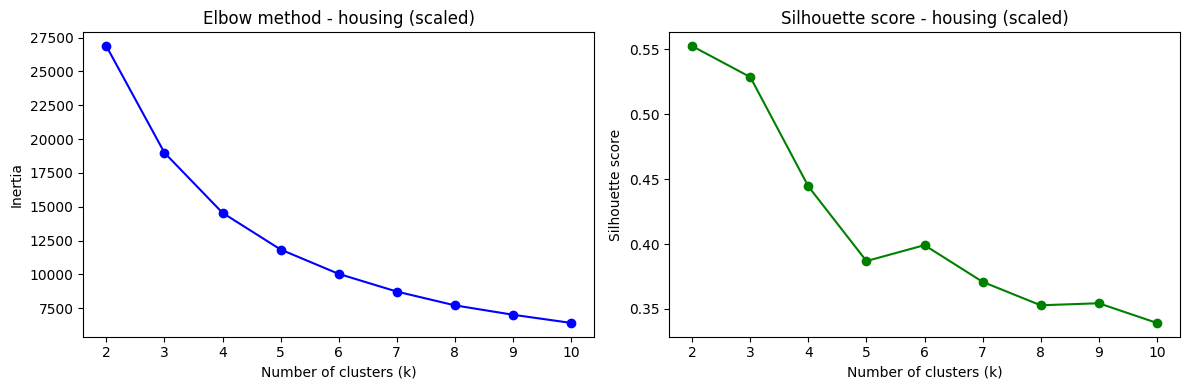

Inertia per k:    [26861.0, 18987.2, 14547.5, 11838.4, 10039.0, 8732.4, 7713.7, 7019.7, 6416.7]
Silhouette per k: [0.5525, 0.5287, 0.4444, 0.3869, 0.3992, 0.3709, 0.3528, 0.3544, 0.3392]

k that maximises silhouette score: 2


In [5]:
k_range_housing = range(2, 11)
inertias_housing = []
sil_scores_housing = []

# silhouette_score is O(n^2); we use a random subsample of the data purely to keep
# this demonstration fast; the elbow (inertia) is still computed on the full dataset.
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled), size=3000, replace=False)

for k in k_range_housing:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias_housing.append(km.inertia_)
    sil_scores_housing.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range_housing), inertias_housing, "bo-")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method - housing (scaled)")

axes[1].plot(list(k_range_housing), sil_scores_housing, "go-")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score - housing (scaled)")
plt.tight_layout()
plt.show()

silhouette_best_k = list(k_range_housing)[int(np.argmax(sil_scores_housing))]
print("Inertia per k:   ", [round(i, 1) for i in inertias_housing])
print("Silhouette per k:", [round(s, 4) for s in sil_scores_housing])
print("\nk that maximises silhouette score:", silhouette_best_k)